# Power consumption

## Matrix mutliplication

not finished jobs
squeue -u (benchlab) bash-5.0$ squeue -u $USER
             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          19328539 hopper-pr l8B_outp julien_d  R 18-23:02:39      1 ip-26-0-161-178
          19328523 hopper-pr l8BC_inp julien_d  R 18-23:06:59      1 ip-26-0-167-175
          19328521 hopper-pr l8B_inpu julien_d  R 18-23:08:08      1 ip-26-0-163-220
(benchlab) bash-5.0$ 

In [1]:
FOLDER = "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/linear_slurm_2025-07-11-15-47-13"
import os 
import pandas as pd

results = []
for csv in os.listdir(FOLDER):
    if csv.endswith(".csv") and 'power' in csv:
        b = int(csv.split("_b")[1].split("_")[0])
        h = int(csv.split("_h")[1].split("_")[0])
        d = int(csv.split("_d")[1].split("_")[0])
        s = int(csv.split("_s")[1].split(".")[0])
        power_df = pd.read_csv(os.path.join(FOLDER, csv))
        max_power = power_df['power_w'].max()
        mean_power = power_df['power_w'].mean()
        min_power = power_df['power_w'].min()
        last_power = power_df['power_w'].iloc[-1]
        results.append({
            'name': csv,
            'batch_size': b,
            'hidden_size': h,
            'dim': d,
            'seq_len': s,
            'max_power': max_power,
            'mean_power': mean_power,
            'min_power': min_power,
            'last_power': last_power
        })
df = pd.DataFrame(results)
df


,name,batch_size,hidden_size,dim,seq_len,max_power,mean_power,min_power,last_power
0,exp1_power_linear_b1_h4096_d11008_s35782.csv,1,4096,11008,35782,712.208,515.065976,261.040,396.287
1,exp1_power_linear_b1_h4096_d11008_s64852.csv,1,4096,11008,64852,785.293,603.020749,211.758,467.289
2,exp1_power_linear_b1_h4096_d11008_s71958.csv,1,4096,11008,71958,782.714,611.004055,231.839,414.975
3,exp1_power_linear_b1_h4096_d11008_s76174.csv,1,4096,11008,76174,714.968,614.533619,239.726,455.694
4,exp1_power_linear_b1_h4096_d11008_s30855.csv,1,4096,11008,30855,725.156,491.847730,223.301,389.098
...,...,...,...,...,...,...,...,...,...
99995,exp1_power_linear_b1_h4096_d11008_s41647.csv,1,4096,11008,41647,711.545,549.134405,253.602,449.840
99996,exp1_power_linear_b1_h4096_d11008_s58910.csv,1,4096,11008,58910,719.267,598.463650,256.218,492.606
99997,exp1_power_linear_b1_h4096_d11008_s98766.csv,1,4096,11008,98766,767.351,635.655299,235.543,459.919
99998,exp1_power_linear_b1_h4096_d11008_s63075.csv,1,4096,11008,63075,763.424,602.810784,238.497,471.205


In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("GPU Power vs Sequence Length", fontsize=16)

# Subplot 1: max_power
axs[0, 0].plot(df['seq_len'], df['max_power'], 'o', alpha=0.7)
axs[0, 0].set_title("Max Power vs Sequence Length")
axs[0, 0].set_xlabel("Sequence Length (s)")
axs[0, 0].set_ylabel("Max Power (W)")

# Subplot 2: mean_power
axs[0, 1].plot(df['seq_len'], df['mean_power'], 'o', alpha=0.7)
axs[0, 1].set_title("Mean Power vs Sequence Length")
axs[0, 1].set_xlabel("Sequence Length (s)")
axs[0, 1].set_ylabel("Mean Power (W)")

# Subplot 3: min_power
axs[1, 0].plot(df['seq_len'], df['min_power'], 'o', alpha=0.7)
axs[1, 0].set_title("Min Power vs Sequence Length")
axs[1, 0].set_xlabel("Sequence Length (s)")
axs[1, 0].set_ylabel("Min Power (W)")

# Subplot 4: last_power
axs[1, 1].plot(df['seq_len'], df['last_power'], 'o', alpha=0.7)
axs[1, 1].set_title("Last Power vs Sequence Length")
axs[1, 1].set_xlabel("Sequence Length (s)")
axs[1, 1].set_ylabel("Last Power (W)")

for ax in axs.flat:
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


: 

## LLM

In [ ]:
FOLDERS = ["/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8B_2025-07-11-16-17-43", # no compile input variation
           "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8B_2025-07-11-16-18-52", # compile input variation
           "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8B_batch_2025-07-11-16-25-21", # no compile batch variation
           "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8BC_batch_2025-07-11-16-25-12", # compile batch variation
           "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8B_output_2025-07-11-16-23-12", # no compile output variation
           "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8BC_output_2025-07-11-16-23-32", # compile output variation
           ]
compile = [True, False, True, False, True, False] # compile input, batch and output variations
import os 
import pandas as pd

results = []
for folder, comp in zip(FOLDERS, compile):
    for csv in os.listdir(folder):
        if csv.endswith(".csv") and 'power' in csv:
            b = int(csv.split("_b")[1].split("_")[0])
            g = int(csv.split("_g")[1].split("_")[0])
            s = int(csv.split("_s")[1].split("_")[0])
            phase = csv.split("trace_")[1].split("_")[0]
            power_df = pd.read_csv(os.path.join(folder, csv))
            max_power = power_df['power_w'].max()
            mean_power = power_df['power_w'].mean()
            min_power = power_df['power_w'].min()
            last_power = power_df['power_w'].iloc[-1]
            results.append({
                'name': csv,
                'phase': phase,
                'compile': comp,
                'batch_size': b,
                'output_length': g,
                'input_length': s,
                'max_power': max_power,
                'mean_power': mean_power,
                'min_power': min_power,
                'last_power': last_power
            })
df_llm = pd.DataFrame(results)
df_llm


: 

In [ ]:
import matplotlib.pyplot as plt

# Filtrage des données : phase = prefill, batch_size = 1
df_filtered = df_llm[(df_llm["phase"] == "prefill") & (df_llm["batch_size"] == 1)]

# Création des 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Prefill Phase — Power vs Input Length (Batch Size = 1)", fontsize=16)

# Fonction pour scatter plot
def scatter_power(ax, y_col, title):
    for comp, label in zip([True, False], ["Compiled", "Non-Compiled"]):
        df_sub = df_filtered[df_filtered["compile"] == comp]
        ax.scatter(df_sub["input_length"], df_sub[y_col], label=label)
    ax.set_title(title)
    ax.set_xlabel("Input Length (s)")
    ax.set_ylabel("Power (W)")
    ax.grid(True)
    ax.legend()

# Subplots
scatter_power(axs[0, 0], "max_power", "Max Power")
scatter_power(axs[0, 1], "mean_power", "Mean Power")
scatter_power(axs[1, 0], "min_power", "Min Power")
scatter_power(axs[1, 1], "last_power", "Last Power")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


: 

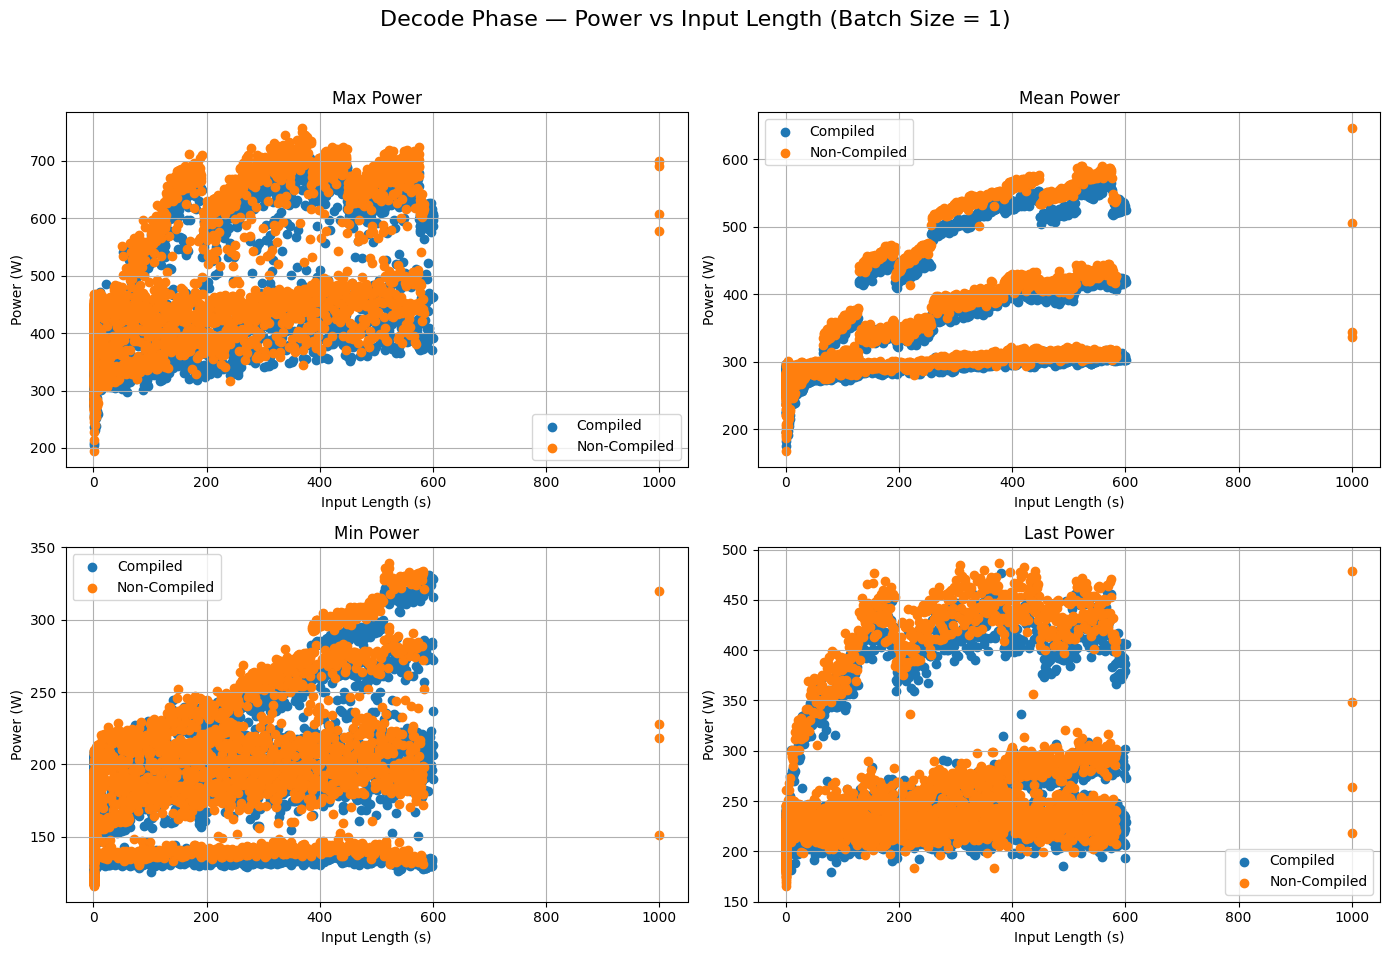

In [5]:
import matplotlib.pyplot as plt

# Filtrage des données : phase = decode, batch_size = 1
df_filtered = df_llm[(df_llm["phase"] == "decode") & (df_llm["batch_size"] == 1)]

# Création des 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Decode Phase — Power vs Input Length (Batch Size = 1)", fontsize=16)

# Fonction pour scatter plot
def scatter_power(ax, y_col, title):
    for comp, label in zip([True, False], ["Compiled", "Non-Compiled"]):
        df_sub = df_filtered[df_filtered["compile"] == comp]
        ax.scatter(df_sub["input_length"], df_sub[y_col], label=label)
    ax.set_title(title)
    ax.set_xlabel("Input Length (s)")
    ax.set_ylabel("Power (W)")
    ax.grid(True)
    ax.legend()

# Subplots
scatter_power(axs[0, 0], "max_power", "Max Power")
scatter_power(axs[0, 1], "mean_power", "Mean Power")
scatter_power(axs[1, 0], "min_power", "Min Power")
scatter_power(axs[1, 1], "last_power", "Last Power")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


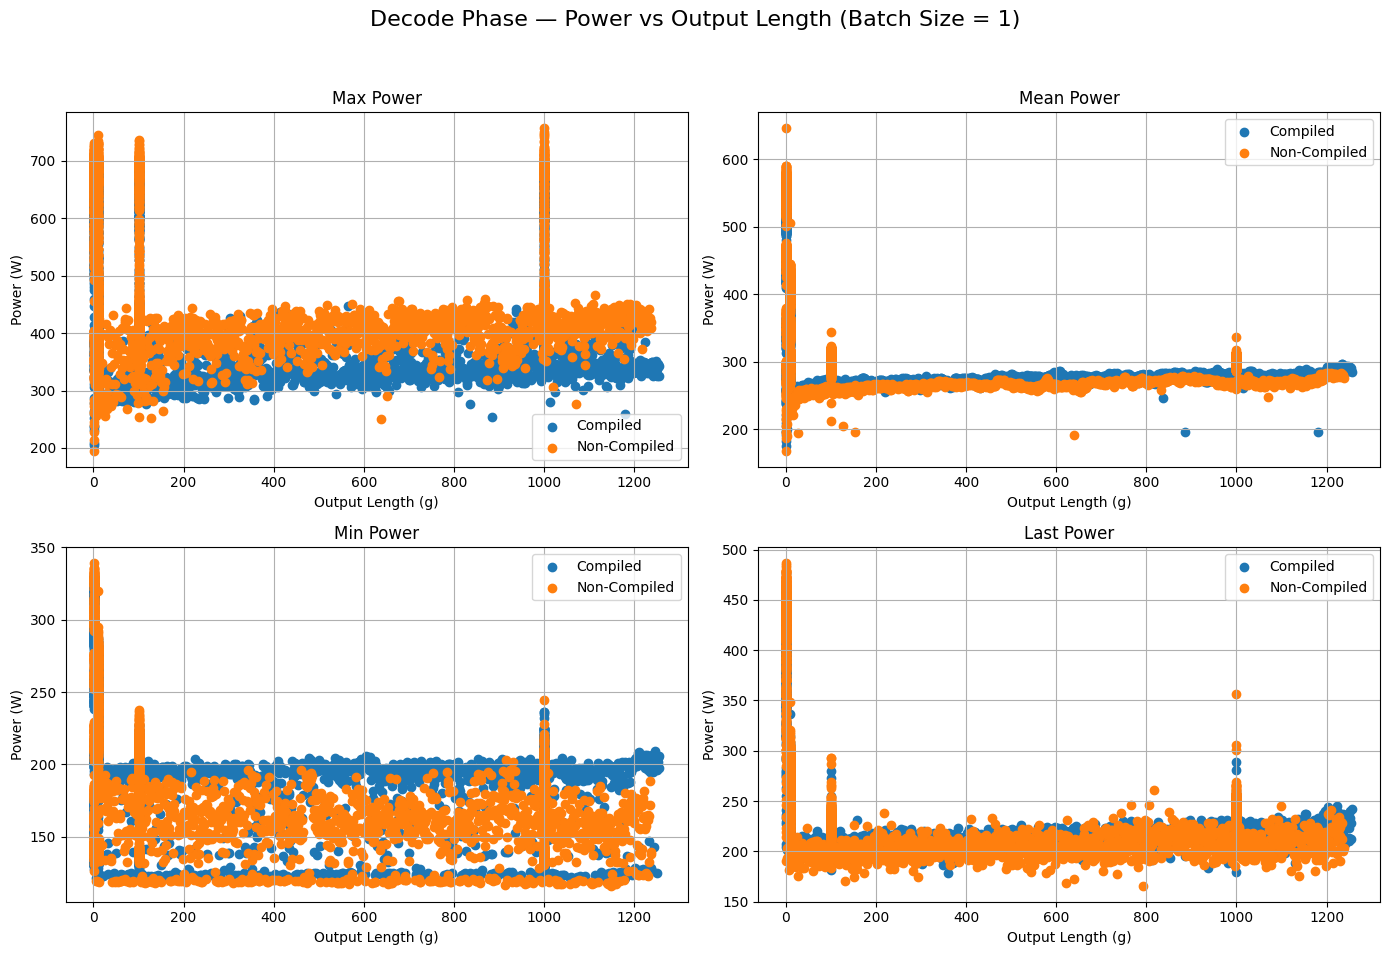

In [6]:
import matplotlib.pyplot as plt

# Filtrage des données : phase = decode, batch_size = 1
df_filtered = df_llm[(df_llm["phase"] == "decode") & (df_llm["batch_size"] == 1)]

# Création des 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Decode Phase — Power vs Output Length (Batch Size = 1)", fontsize=16)

# Fonction pour scatter plot
def scatter_power(ax, y_col, title):
    for comp, label in zip([True, False], ["Compiled", "Non-Compiled"]):
        df_sub = df_filtered[df_filtered["compile"] == comp]
        ax.scatter(df_sub["output_length"], df_sub[y_col], label=label)
    ax.set_title(title)
    ax.set_xlabel("Output Length (g)")
    ax.set_ylabel("Power (W)")
    ax.grid(True)
    ax.legend()

# Subplots
scatter_power(axs[0, 0], "max_power", "Max Power")
scatter_power(axs[0, 1], "mean_power", "Mean Power")
scatter_power(axs[1, 0], "min_power", "Min Power")
scatter_power(axs[1, 1], "last_power", "Last Power")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Energy consumption

### Matrix multiplication

In [11]:
FOLDER = "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/linear_slurm_2025-07-11-15-47-13"
df_energy_gemm = pd.read_csv(FOLDER + "/exp1_linear_benchmark_2025-07-15-09-17-12.csv")
df_energy_gemm

,model_id,runs,warmup_runs,batch_size,hidden_dim,ffn_dim,seq_len,latency_ms,energy_cpu_Wh,energy_gpu_Wh,energy_ram_Wh
0,linear,20,5,1,4096,11008,1,0.076382,3.318546e-09,4.799232e-09,1.506303e-09
1,linear,20,5,1,4096,11008,2,0.083238,3.217822e-09,4.798383e-09,1.492843e-09
2,linear,20,5,1,4096,11008,3,0.100139,3.948851e-09,4.770914e-09,1.522490e-09
3,linear,20,5,1,4096,11008,4,0.098805,3.133824e-09,4.769294e-09,1.494923e-09
4,linear,20,5,1,4096,11008,5,0.093834,3.642271e-09,4.819062e-09,1.500194e-09
...,...,...,...,...,...,...,...,...,...,...,...
99995,linear,20,5,1,4096,11008,99996,183.753723,1.586950e-08,2.295443e-07,1.340072e-08
99996,linear,20,5,1,4096,11008,99997,184.443652,1.589217e-08,2.255587e-07,1.341984e-08
99997,linear,20,5,1,4096,11008,99998,183.693372,1.586713e-08,2.286304e-07,1.339871e-08
99998,linear,20,5,1,4096,11008,99999,184.130945,1.587981e-08,2.295510e-07,1.340942e-08


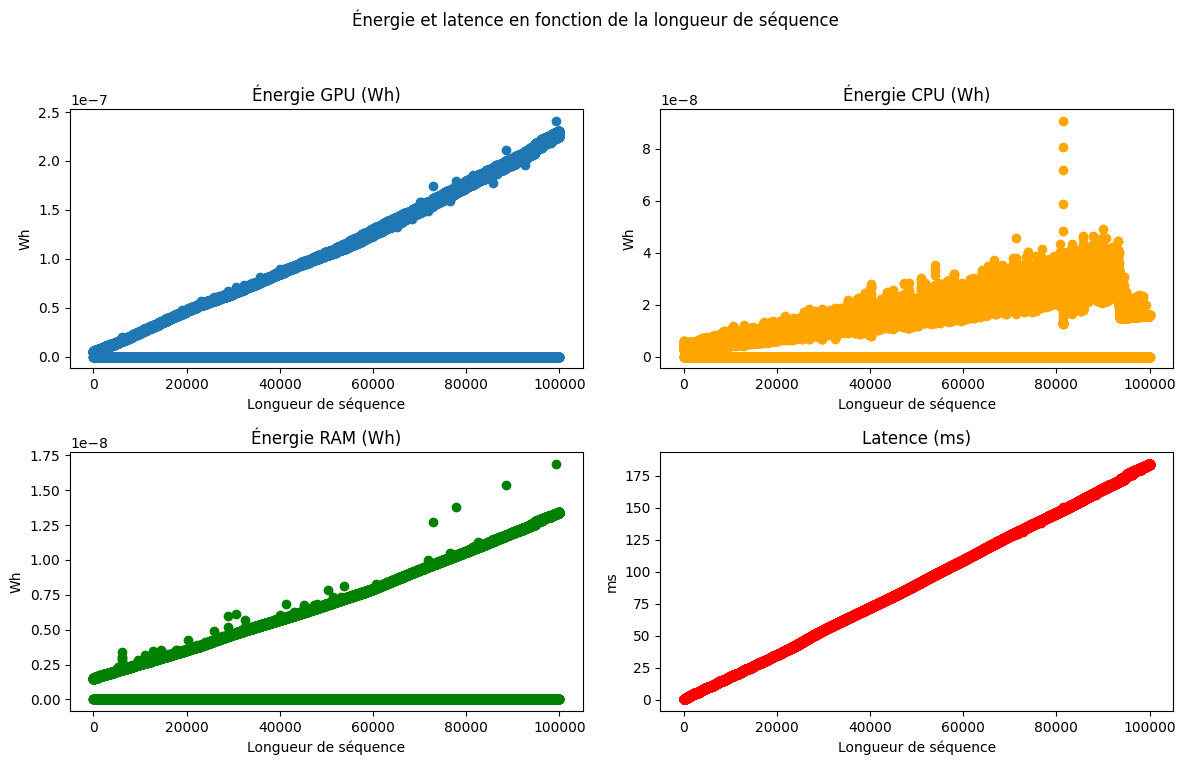

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Optionnel : trier les données par seq_len pour une courbe plus propre
df_energy_gemm = df_energy_gemm.sort_values("seq_len")

# Création de la figure avec 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Énergie et latence en fonction de la longueur de séquence")

# Plot énergie GPU
axs[0, 0].scatter(df_energy_gemm["seq_len"], df_energy_gemm["energy_gpu_Wh"], marker='o')
axs[0, 0].set_title("Énergie GPU (Wh)")
axs[0, 0].set_xlabel("Longueur de séquence")
axs[0, 0].set_ylabel("Wh")

# Plot énergie CPU
axs[0, 1].scatter(df_energy_gemm["seq_len"], df_energy_gemm["energy_cpu_Wh"], marker='o', color='orange')
axs[0, 1].set_title("Énergie CPU (Wh)")
axs[0, 1].set_xlabel("Longueur de séquence")
axs[0, 1].set_ylabel("Wh")

# Plot énergie RAM
axs[1, 0].scatter(df_energy_gemm["seq_len"], df_energy_gemm["energy_ram_Wh"], marker='o', color='green')
axs[1, 0].set_title("Énergie RAM (Wh)")
axs[1, 0].set_xlabel("Longueur de séquence")
axs[1, 0].set_ylabel("Wh")

# Plot latence
axs[1, 1].scatter(df_energy_gemm["seq_len"], df_energy_gemm["latency_ms"], marker='o', color='red')
axs[1, 1].set_title("Latence (ms)")
axs[1, 1].set_xlabel("Longueur de séquence")
axs[1, 1].set_ylabel("ms")

# Ajustement automatique de l’espacement
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
